# ShearNet / ngmix Analysis Notebook

**Two input files:**
- `METACAL_FITS` — output of the metacal shear-pair script (`TAB_P` / `TAB_M` HDUs). Used for shear residuals, size, flux, and R₁₁ diagnostics.
- `PSF_LEAKAGE_FITS` — output of the PSF leakage measurement script. Used for PSF leakage panels.

## 0 · Imports

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

import superbit_lensing.plotter as plotter
from shearnet.utils.plot_helpers import (
    plot_residuals,
    plot_true_vs_predicted,
)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 11,
})

COLORS = {
    'ngmix':    ('#3B4CC0', '#B40426'),
    'shearnet': ('#2ca02c', '#ff7f0e'),
}

## 1 · Configuration

In [2]:
import os

# ── input files ──────────────────────────────────────────────────────────────
METACAL_FITS     = '/home/adfield/ShearNet/unit_tests/second/benchmarking/m/metacal_results.fits'
PSF_LEAKAGE_FITS = '/home/adfield/ShearNet/unit_tests/second/benchmarking/psf_leakage/psf_leakage_results.fits'

# ── output directories (derived from file locations) ─────────────────────────
METACAL_DIR  = os.path.dirname(METACAL_FITS)
LEAKAGE_DIR  = os.path.dirname(PSF_LEAKAGE_FITS)

print(f"Metacal plots  → {METACAL_DIR}")
print(f"Leakage plots  → {LEAKAGE_DIR}")

# ── quality cuts applied to the metacal table (set to None to skip) ─────────
S2N_MIN    = 10.0
T_TPSF_MIN = 0.5

# ── PSF leakage panel settings ───────────────────────────────────────────────
NBIN      = 10
MIN_COUNT = 20
CALIBRATE = False
NJAC      = 30


Metacal plots  → /home/adfield/ShearNet/unit_tests/second/benchmarking/m
Leakage plots  → /home/adfield/ShearNet/unit_tests/second/benchmarking/psf_leakage


## 2 · Load metacal data

In [3]:
tab_p = Table.read(METACAL_FITS, hdu='TAB_P')
tab_m = Table.read(METACAL_FITS, hdu='TAB_M')
print(f'TAB_P rows : {len(tab_p)}')
print(f'TAB_M rows : {len(tab_m)}')
print(f'Columns    : {tab_p.colnames}')

def _get(tab, col, fallback=None):
    """Return np array for col if it exists, else fallback (None → all-NaN)."""
    if col in tab.colnames:
        return np.asarray(tab[col])
    if fallback is not None:
        return fallback
    # infer shape from first numeric column
    ref = np.asarray(tab[tab.colnames[0]])
    return np.full(len(ref), np.nan)

# ── ngmix noshear quantities ──────────────────────────────────────────────────
g_ngmix = _get(tab_p, 'g_noshear')       # (N, 2)
g_th    = _get(tab_p, 'g_th')            # (N, 2)
s2n     = _get(tab_p, 's2n_noshear')
T_gal   = _get(tab_p, 'T_noshear')
T_psf   = _get(tab_p, 'Tpsf_noshear')
gpsf    = _get(tab_p, 'gpsf_noshear')   # (N, 2)
flags   = _get(tab_p, 'flag')
flux_ng  = _get(tab_p, 'flux_noshear')

# ── metacal responses (r22 may be absent if only 1p/1m types were run) ────────
r11    = _get(tab_p, 'r11')
r22    = _get(tab_p, 'r22')    # will be all-NaN if 2p/2m not in TYPES

HAS_R22 = 'r22' in tab_p.colnames and not np.all(np.isnan(r22))
print(f'r22 available: {HAS_R22}')

# ── ShearNet quantities ───────────────────────────────────────────────────────
g_sn_noshear = _get(tab_p, 'g_sn_noshear')  # (N, 2)
g_sn_raw     = _get(tab_p, 'g_sn_raw')      # (N, 2)
r11_sn       = _get(tab_p, 'r11_sn')
r22_sn       = _get(tab_p, 'r22_sn')
g_sn_sigma = _get(tab_p, 'g_sn_sigma')   # (N,) or all-NaN
g_sn_flux  = _get(tab_p, 'g_sn_flux')    # (N,) or all-NaN

HAS_SN_SIGMA = not np.all(np.isnan(g_sn_sigma))
HAS_SN_FLUX  = not np.all(np.isnan(g_sn_flux))

HAS_SN = not np.all(np.isnan(g_sn_noshear))
print(f'ShearNet predictions present: {HAS_SN}')

gal_hlr_th  = _get(tab_p, 'gal_hlr_th')
gal_flux_th = _get(tab_p, 'gal_flux_th')

# ── quality cut ───────────────────────────────────────────────────────────────
sel = (flags == 0) & np.isfinite(g_ngmix[:, 0]) & np.isfinite(T_gal)
if S2N_MIN is not None:
    sel &= (s2n > S2N_MIN)
if T_TPSF_MIN is not None:
    sel &= (T_gal / np.where(T_psf > 0, T_psf, np.nan) > T_TPSF_MIN)

print(f'Objects passing cuts: {sel.sum()} / {len(sel)}')

# ── masked working arrays ─────────────────────────────────────────────────────
G_NG    = g_ngmix[sel]
G_TH    = g_th[sel]
S2N_    = s2n[sel]
TG_     = T_gal[sel]
TP_     = T_psf[sel]
GPSF_   = gpsf[sel]
R11_    = r11[sel]
R22_    = r22[sel]
G_SN    = g_sn_noshear[sel]
G_SN_R  = g_sn_raw[sel]
R11_SN_ = r11_sn[sel]
R22_SN_ = r22_sn[sel]
HLR_TH_  = gal_hlr_th[sel]
FLUX_TH_ = gal_flux_th[sel]
G_SN_SIGMA = g_sn_sigma[sel]
G_SN_FLUX  = g_sn_flux[sel]
FLUX_NG = flux_ng[sel]

TAB_P rows : 200000
TAB_M rows : 200000
Columns    : ['flag', 's2n_noshear', 'g_noshear', 'T_noshear', 'Tpsf_noshear', 'gpsf_noshear', 'g_sn_noshear', 'flux_noshear', 's2n_1p', 'g_1p', 'T_1p', 'Tpsf_1p', 'gpsf_1p', 'g_sn_1p', 'flux_1p', 's2n_1m', 'g_1m', 'T_1m', 'Tpsf_1m', 'gpsf_1m', 'g_sn_1m', 'flux_1m', 'r11', 'r11_sn', 'g_th', 'gal_hlr_th', 'gal_flux_th', 'psf_x_im', 'psf_y_im', 'g_sn_sigma', 'g_sn_flux', 'g_sn_raw']
r22 available: False
ShearNet predictions present: True
Objects passing cuts: 200000 / 200000


## 3 · Load PSF leakage data

In [4]:
cat_lk = Table.read(PSF_LEAKAGE_FITS)
print(f'PSF leakage rows: {len(cat_lk)}')
print(f'Columns: {cat_lk.colnames}')

e1_psf_lk = np.asarray(cat_lk['gpsf'][:, 0])
e2_psf_lk = np.asarray(cat_lk['gpsf'][:, 1])
e1_gal_lk = np.asarray(cat_lk['g'][:, 0])
e2_gal_lk = np.asarray(cat_lk['g'][:, 1])

g_sn_lk   = np.asarray(cat_lk['g_sn']) if 'g_sn' in cat_lk.colnames \
             else np.full((len(cat_lk), 2), np.nan)
HAS_SN_LK = not np.all(np.isnan(g_sn_lk))
print(f'ShearNet predictions in leakage file: {HAS_SN_LK}')

if HAS_SN_LK:
    e1_sn_lk = g_sn_lk[:, 0]
    e2_sn_lk = g_sn_lk[:, 1]

# shared x-axis list reused by leakage cells below
x_list = [
    (e1_psf_lk, r'$e_1^{\rm PSF}$'),
    (e2_psf_lk, r'$e_2^{\rm PSF}$'),
]

PSF leakage rows: 200000
Columns: ['s2n', 'g', 'T', 'Tpsf', 'gpsf', 'g_sn', 'flag', 'g_th', 'gal_hlr_th', 'gal_flux_th']
ShearNet predictions in leakage file: True


## 4 · g₁, g₂ residuals  (+ σ proxy)

`plot_residuals` and `plot_true_vs_predicted` from `shearnet.utils.plot_helpers` expect
`(N, 4)` arrays shaped `[g1, g2, sigma, flux]`.
We construct these from the FITS columns: σ = √(T/2), flux = S/N.
Truth sigma/flux are not stored in the bias FITS, so those panels show
measured − measured (centred near zero by construction) and serve as a
self-consistency check rather than a residual vs truth.


=== ShearNet residuals (vs truth g1/g2, vs ngmix sigma/flux) ===
Saved → /home/adfield/ShearNet/unit_tests/second/benchmarking/m/residuals_shearnet.png


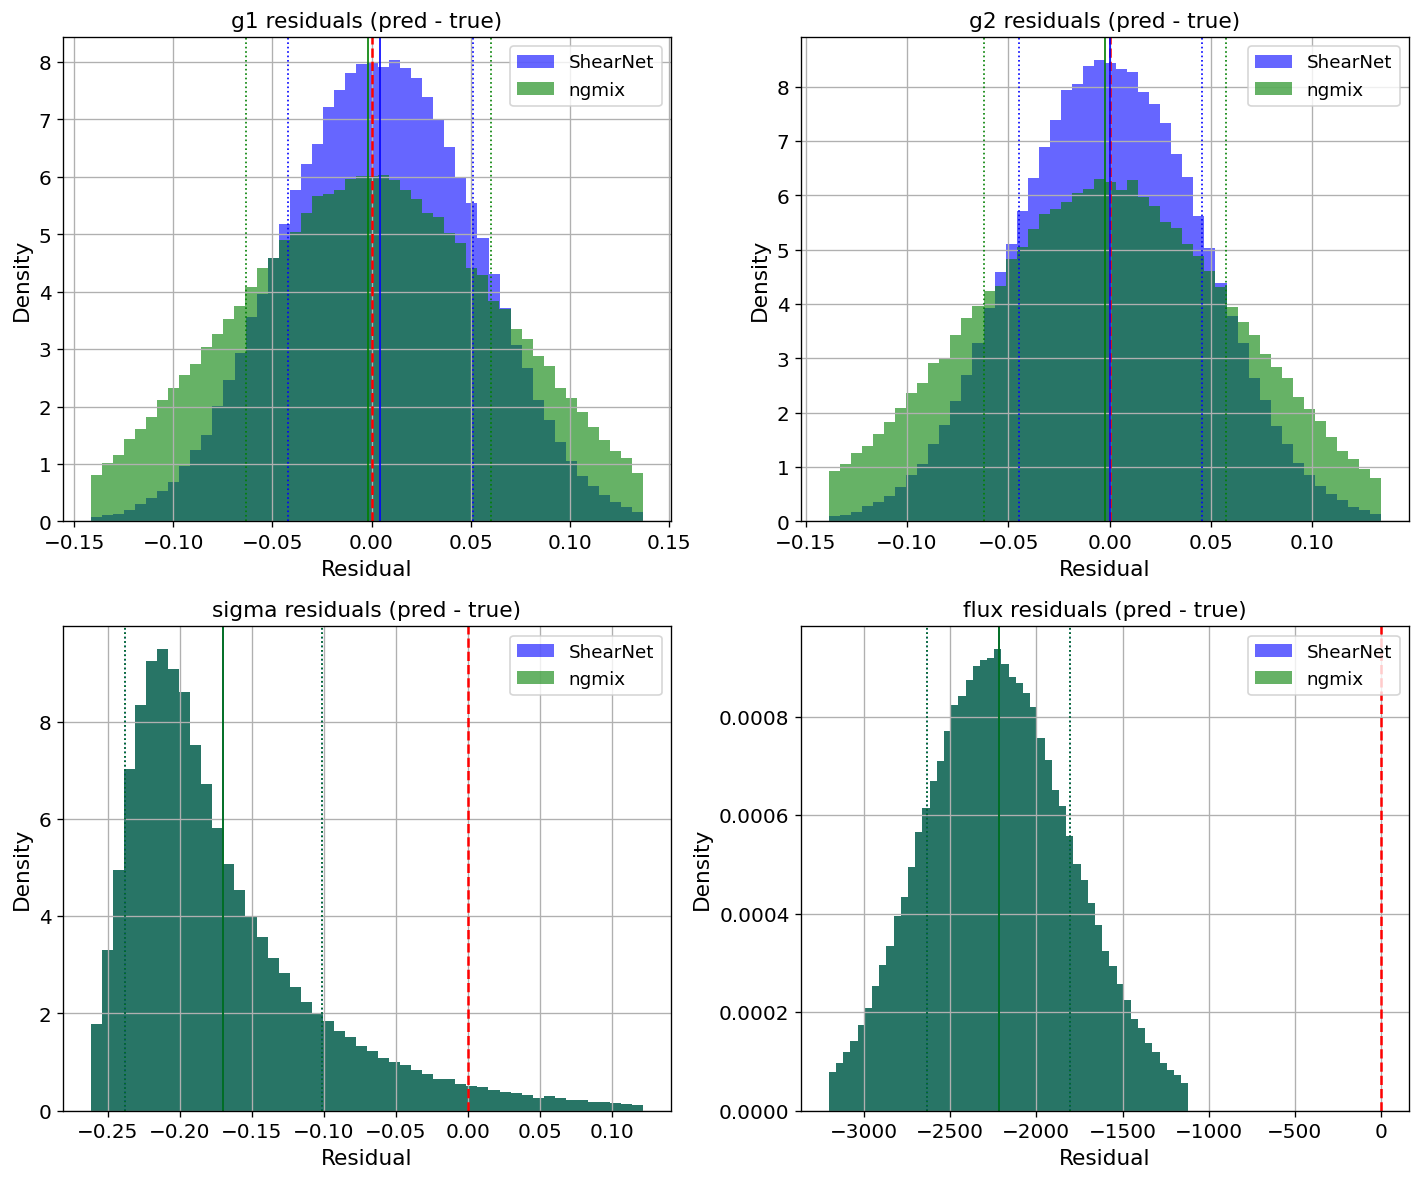

In [5]:
# ── build (N, 4) arrays expected by plot_helpers ────────────────────────────
sigma_ng     = np.sqrt(np.abs(TG_) / 2.0)

# true sigma: convert catalog HLR to T convention: T = 2*HLR^2
true_sigma = np.sqrt(2) * HLR_TH_   # sqrt(T/2) = sqrt(2*HLR^2/2) = HLR

true_4    = np.column_stack([G_TH, true_sigma, FLUX_TH_])
pred_ng_4 = np.column_stack([G_NG, sigma_ng, FLUX_NG])

# ── ShearNet residuals ────────────────────────────────────────────────────────
if HAS_SN:
    sn_sigma_col = G_SN_SIGMA if HAS_SN_SIGMA else sigma_ng
    sn_flux_col  = G_SN_FLUX  if HAS_SN_FLUX  else FLUX_NG
    pred_sn_4 = np.column_stack([G_SN, sn_sigma_col, sn_flux_col])

    print("\n=== ShearNet residuals (vs truth g1/g2, vs ngmix sigma/flux) ===")
    plot_residuals(
        true_labels=true_4,
        predicted_labels=pred_sn_4,
        preds_ngmix=pred_ng_4,
        path=os.path.join(METACAL_DIR, "residuals_shearnet"),
    )
    print(f"Saved → {os.path.join(METACAL_DIR, 'residuals_shearnet.png')}")
else:
    # ── ngmix residuals ──────────────────────────────────────────────────────────
    print("=== ngmix residuals ===")
    plot_residuals(
        true_labels=true_4,
        predicted_labels=pred_ng_4,
        preds_ngmix=pred_ng_4,
        path=os.path.join(METACAL_DIR, "residuals_ngmix.png"),
    )
    print(f"Saved → {os.path.join(METACAL_DIR, 'residuals_ngmix.png')}")


## 4b · True vs predicted  (`plot_true_vs_predicted`)

In [6]:
plot_true_vs_predicted(
    true_labels=true_4,
    predicted_labels=pred_ng_4,
    preds_mcal=pred_ng_4,
    mcal=True,
    path=os.path.join(METACAL_DIR, "true_vs_pred_ngmix"),
)

if HAS_SN:
    plot_true_vs_predicted(
        true_labels=true_4,
        predicted_labels=pred_sn_4,
        preds_mcal=pred_ng_4,
        mcal=True,
        path=os.path.join(METACAL_DIR, "true_vs_pred_shearnet"),
    )


## 5 · Size (T / σ) distributions

Median T_gal / T_PSF = 6.078
Median sigma_gal     = 0.5178 arcsec
Median sigma_PSF     = 0.2086 arcsec
Saved → /home/adfield/ShearNet/unit_tests/second/benchmarking/m/size_distributions.png


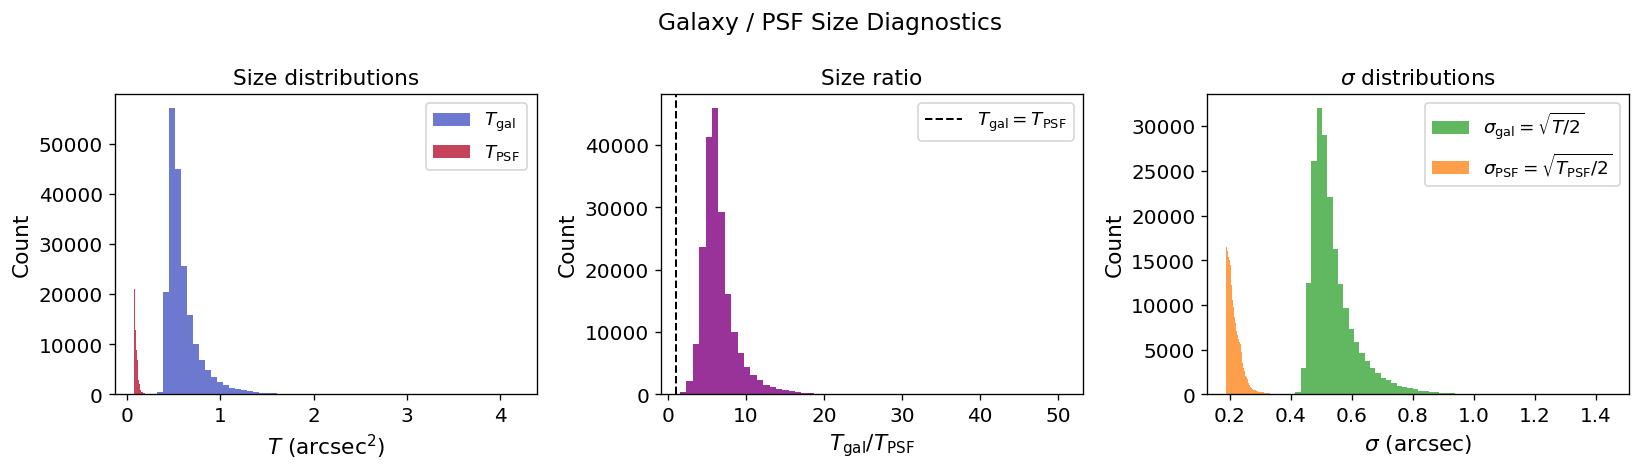

In [7]:
T_ratio    = TG_ / np.where(TP_ > 0, TP_, np.nan)
T_sigma    = np.sqrt(np.abs(TG_) / 2.0)
Tpsf_sigma = np.sqrt(np.abs(TP_) / 2.0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(TG_[np.isfinite(TG_)], bins=60, color=COLORS['ngmix'][0], alpha=0.75,
             label=r'$T_{\rm gal}$')
axes[0].hist(TP_[np.isfinite(TP_)], bins=60, color=COLORS['ngmix'][1], alpha=0.75,
             label=r'$T_{\rm PSF}$')
axes[0].set_xlabel(r'$T$ (arcsec$^2$)')
axes[0].set_ylabel('Count')
axes[0].set_title('Size distributions')
axes[0].legend()

axes[1].hist(T_ratio[np.isfinite(T_ratio)], bins=60, color='purple', alpha=0.8)
axes[1].axvline(1.0, color='k', ls='--', lw=1.2,
                label=r'$T_{\rm gal} = T_{\rm PSF}$')
axes[1].set_xlabel(r'$T_{\rm gal} / T_{\rm PSF}$')
axes[1].set_ylabel('Count')
axes[1].set_title('Size ratio')
axes[1].legend()

axes[2].hist(T_sigma[np.isfinite(T_sigma)], bins=60,
             color=COLORS['shearnet'][0], alpha=0.75,
             label=r'$\sigma_{\rm gal} = \sqrt{T/2}$')
axes[2].hist(Tpsf_sigma[np.isfinite(Tpsf_sigma)], bins=60,
             color=COLORS['shearnet'][1], alpha=0.75,
             label=r'$\sigma_{\rm PSF} = \sqrt{T_{\rm PSF}/2}$')
axes[2].set_xlabel(r'$\sigma$ (arcsec)')
axes[2].set_ylabel('Count')
axes[2].set_title(r'$\sigma$ distributions')
axes[2].legend()

plt.suptitle('Galaxy / PSF Size Diagnostics', fontsize=14)
plt.tight_layout()

print(f'Median T_gal / T_PSF = {np.nanmedian(T_ratio):.3f}')
print(f'Median sigma_gal     = {np.nanmedian(T_sigma):.4f} arcsec')
print(f'Median sigma_PSF     = {np.nanmedian(Tpsf_sigma):.4f} arcsec')
plt.savefig(os.path.join(METACAL_DIR, "size_distributions.png"), dpi=150, bbox_inches="tight")
print(f"Saved → {os.path.join(METACAL_DIR, 'size_distributions.png')}")


## 6 · Flux / S/N distributions

Median S/N = 41.23
Mean   S/N = 40.92
S/N range  = [24.29, 47.66]
Saved → /home/adfield/ShearNet/unit_tests/second/benchmarking/m/snr_distributions.png


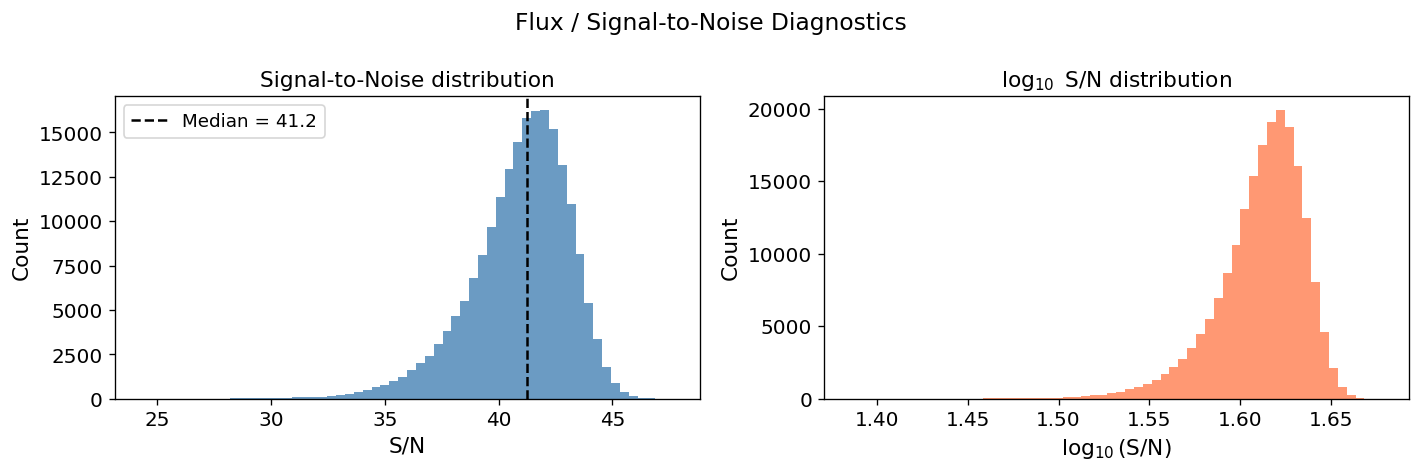

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

valid_sn = np.isfinite(S2N_) & (S2N_ > 0)
axes[0].hist(S2N_[valid_sn], bins=60, color='steelblue', alpha=0.8)
axes[0].axvline(np.nanmedian(S2N_), color='k', ls='--', lw=1.5,
                label=f'Median = {np.nanmedian(S2N_):.1f}')
axes[0].set_xlabel('S/N')
axes[0].set_ylabel('Count')
axes[0].set_title('Signal-to-Noise distribution')
axes[0].legend()

axes[1].hist(np.log10(S2N_[valid_sn]), bins=60, color='coral', alpha=0.8)
axes[1].set_xlabel(r'$\log_{10}(\mathrm{S/N})$')
axes[1].set_ylabel('Count')
axes[1].set_title(r'$\log_{10}$ S/N distribution')

plt.suptitle('Flux / Signal-to-Noise Diagnostics', fontsize=14)
plt.tight_layout()

print(f'Median S/N = {np.nanmedian(S2N_):.2f}')
print(f'Mean   S/N = {np.nanmean(S2N_):.2f}')
print(f'S/N range  = [{np.nanmin(S2N_):.2f}, {np.nanmax(S2N_):.2f}]')
plt.savefig(os.path.join(METACAL_DIR, "snr_distributions.png"), dpi=150, bbox_inches="tight")
print(f"Saved → {os.path.join(METACAL_DIR, 'snr_distributions.png')}")


## 7 · R₁₁ response histogram

ngmix   : <R11> = 0.7738  (r22 not computed)
ShearNet: <R11> = 1.1045  (r22_sn not computed)
Saved -> /home/adfield/ShearNet/unit_tests/second/benchmarking/m/r11_response.png


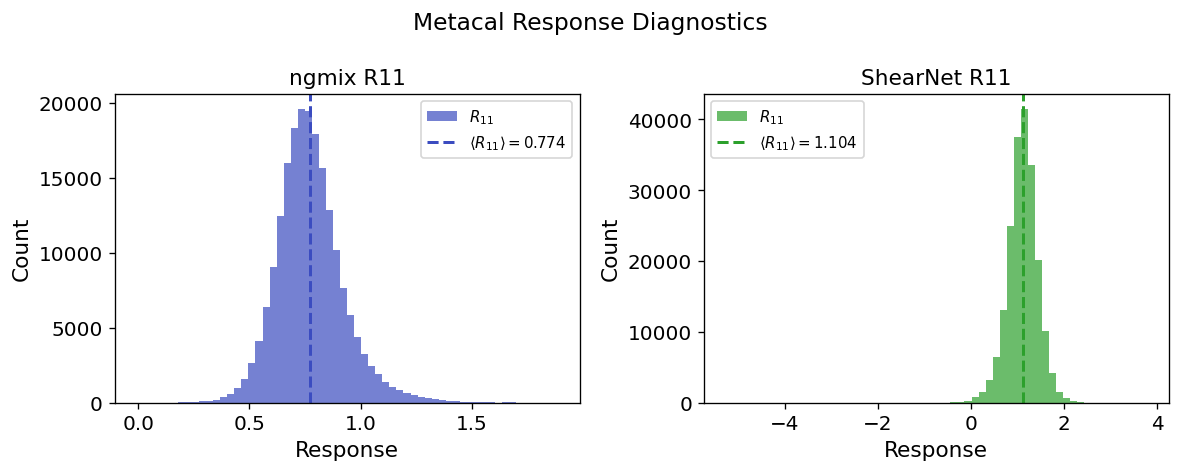

In [9]:
valid_r = np.isfinite(R11_)

# Build list of panels dynamically so missing columns don't break anything
panels = []
panels.append(('ngmix R11', R11_, R22_, COLORS['ngmix'], 'r11', 'r22', HAS_R22))
if HAS_SN:
    has_r22_sn = not np.all(np.isnan(R22_SN_))
    panels.append(('ShearNet R11', R11_SN_, R22_SN_, COLORS['shearnet'], 'r11_sn', 'r22_sn', has_r22_sn))

fig, axes = plt.subplots(1, len(panels),
                         figsize=(5 * len(panels), 4))
if len(panels) == 1:
    axes = [axes]

for ax, (title, r11_arr, r22_arr, cols, r11_lbl, r22_lbl, has_r22) in zip(axes, panels):
    vr = np.isfinite(r11_arr)
    ax.hist(r11_arr[vr], bins=60, color=cols[0], alpha=0.7,
            label=rf'$R_{{11}}$')
    ax.axvline(np.nanmean(r11_arr), color=cols[0], ls='--', lw=1.8,
               label=rf'$\langle R_{{11}} \rangle = {np.nanmean(r11_arr):.3f}$')
    if has_r22:
        vr2 = np.isfinite(r22_arr)
        ax.hist(r22_arr[vr2], bins=60, color=cols[1], alpha=0.7,
                label=rf'$R_{{22}}$')
        ax.axvline(np.nanmean(r22_arr), color=cols[1], ls='-.', lw=1.8,
                   label=rf'$\langle R_{{22}} \rangle = {np.nanmean(r22_arr):.3f}$')
    ax.set_xlabel('Response')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle('Metacal Response Diagnostics', fontsize=14)
plt.tight_layout()

print(f'ngmix   : <R11> = {np.nanmean(R11_):.4f}' +
      (f'   <R22> = {np.nanmean(R22_):.4f}' if HAS_R22 else '  (r22 not computed)'))
if HAS_SN:
    print(f'ShearNet: <R11> = {np.nanmean(R11_SN_):.4f}' +
          (f'   <R22> = {np.nanmean(R22_SN_):.4f}' if not np.all(np.isnan(R22_SN_)) else '  (r22_sn not computed)'))
plt.savefig(os.path.join(METACAL_DIR, "r11_response.png"), dpi=150, bbox_inches="tight")
print(f"Saved -> {os.path.join(METACAL_DIR, 'r11_response.png')}")


## 7b · R₁₁ vs S/N  (ngmix & ShearNet, binned)

Quantile-binned median R₁₁ as a function of S/N for both estimators on the same axes.
Shaded band = ±1 SE; dashed line = bin median.

Saved -> /home/adfield/ShearNet/unit_tests/second/benchmarking/m/r11_vs_snr.png


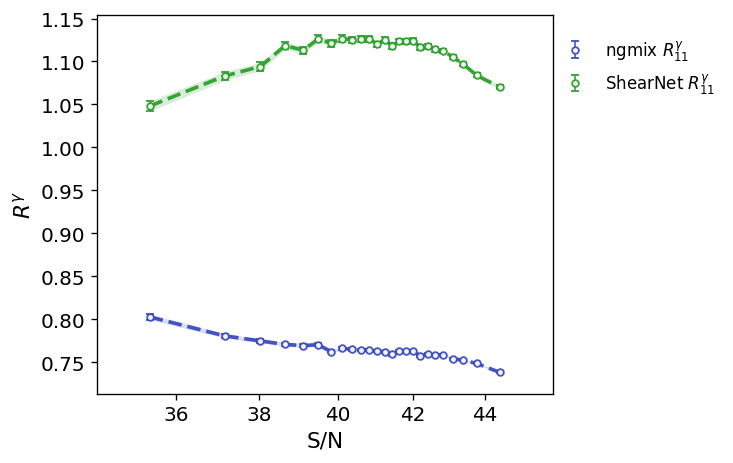

In [10]:
# ── bin pre-computed arrays the same way process_catalog does ────────────────
def _bin_response(r_arr, snr_arr, n_bins=25):
    valid = np.isfinite(r_arr) & np.isfinite(snr_arr) & (snr_arr > 0)
    r, s = r_arr[valid], snr_arr[valid]
    edges = np.percentile(s, np.linspace(0, 100, n_bins + 1))
    idx = np.digitize(s, edges)
    centers, meds, errs = [], [], []
    for i in range(1, len(edges)):
        mask = idx == i
        if mask.sum() > 0:
            centers.append(np.median(s[mask]))
            meds.append(np.median(r[mask]))
            errs.append(np.std(r[mask]) / np.sqrt(mask.sum()))
    return np.array(centers), np.array(meds), np.array(errs)


# ── verbatim from representation.ipynb ───────────────────────────────────────
def _as_sorted(x, y, e):
    x, y, e = np.asarray(x), np.asarray(y), np.asarray(e)
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(e)
    x, y, e = x[m], y[m], e[m]
    s = np.argsort(x)
    return x[s], y[s], e[s]


def style_log_x(ax, xlo, xhi):
    import matplotlib.ticker as mticker
    ax.set_xscale("log")
    # pick ~5 round tick values within the data range
    candidates = np.arange(np.ceil(xlo / 2) * 2, np.floor(xhi / 2) * 2 + 1, 2).astype(int)
    ticks = candidates[(candidates >= xlo) & (candidates <= xhi)]
    if len(ticks) < 2:
        ticks = np.linspace(xlo, xhi, 5).astype(int)
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.tick_params(which="both", direction="out", top=False, right=False)


fig, ax = plt.subplots(1, 1, figsize=(6, 3.75), constrained_layout=True)

has_r22_sn = HAS_SN and not np.all(np.isnan(R22_SN_))

estimators = [
    {
        'label': 'ngmix',
        'components': [
            ('r11', R11_,    COLORS['ngmix'][0]),
            ('r22', R22_,    COLORS['ngmix'][1]),
        ] if HAS_R22 else [
            ('r11', R11_,    COLORS['ngmix'][0]),
        ],
    },
]
if HAS_SN:
    estimators.append({
        'label': 'ShearNet',
        'components': [
            ('r11', R11_SN_, COLORS['shearnet'][0]),
            ('r22', R22_SN_, COLORS['shearnet'][1]),
        ] if has_r22_sn else [
            ('r11', R11_SN_, COLORS['shearnet'][0]),
        ],
    })

ymin, ymax = np.inf, -np.inf

for est in estimators:
    for comp_label, r_arr, col in est['components']:
        x, y, e = _as_sorted(*_bin_response(r_arr, S2N_))

        ax.fill_between(
            x, y - e, y + e,
            color=col, alpha=0.18, linewidth=0, zorder=1
        )
        ax.plot(
            x, y,
            c=col, ls="--", lw=2.2, alpha=0.95, zorder=2
        )
        ax.errorbar(
            x, y, yerr=e,
            c=col, fmt="o", ms=4.0,
            mfc="white", mew=1.1,
            capsize=2.5, elinewidth=1.0, lw=0,
            alpha=0.95, zorder=3,
            label=fr"{est['label']} $R^{{\gamma}}_{{{'11' if comp_label == 'r11' else '22'}}}$"
        )

        ymin = min(ymin, np.nanmin(y - e))
        ymax = max(ymax, np.nanmax(y + e))

ypad = 0.06 * (ymax - ymin) if np.isfinite(ymax - ymin) else 0.05
ax.set_ylim(ymin - ypad, ymax + ypad)

# x bounds: tight around the data with ~20% log-space padding
all_x = np.concatenate([
    _bin_response(r_arr, S2N_)[0]
    for est in estimators
    for _, r_arr, _ in est['components']
])
all_x = all_x[np.isfinite(all_x) & (all_x > 0)]
log_pad = 0.15 * (np.log10(all_x.max()) - np.log10(all_x.min()))
xlo = 10 ** (np.log10(all_x.min()) - log_pad)
xhi = 10 ** (np.log10(all_x.max()) + log_pad)
ax.set_xlim(xlo, xhi)
style_log_x(ax, xlo, xhi)

ax.set_xlabel("S/N")
ax.set_ylabel(r"$R^{\gamma}$")
ax.legend(frameon=False, fontsize=10, loc="upper left",
          bbox_to_anchor=(0.98, 0.98))

plt.savefig(os.path.join(METACAL_DIR, "r11_vs_snr.png"), dpi=150, bbox_inches="tight")
print(f"Saved -> {os.path.join(METACAL_DIR, 'r11_vs_snr.png')}")


## 8 · PSF leakage — ngmix
Uses `PSFLeakagePanelMaker` from `superbit_lensing.plotter`, exactly as in the reference notebook.

Saved → /home/adfield/ShearNet/unit_tests/second/benchmarking/psf_leakage/psf_leakage_ngmix.png


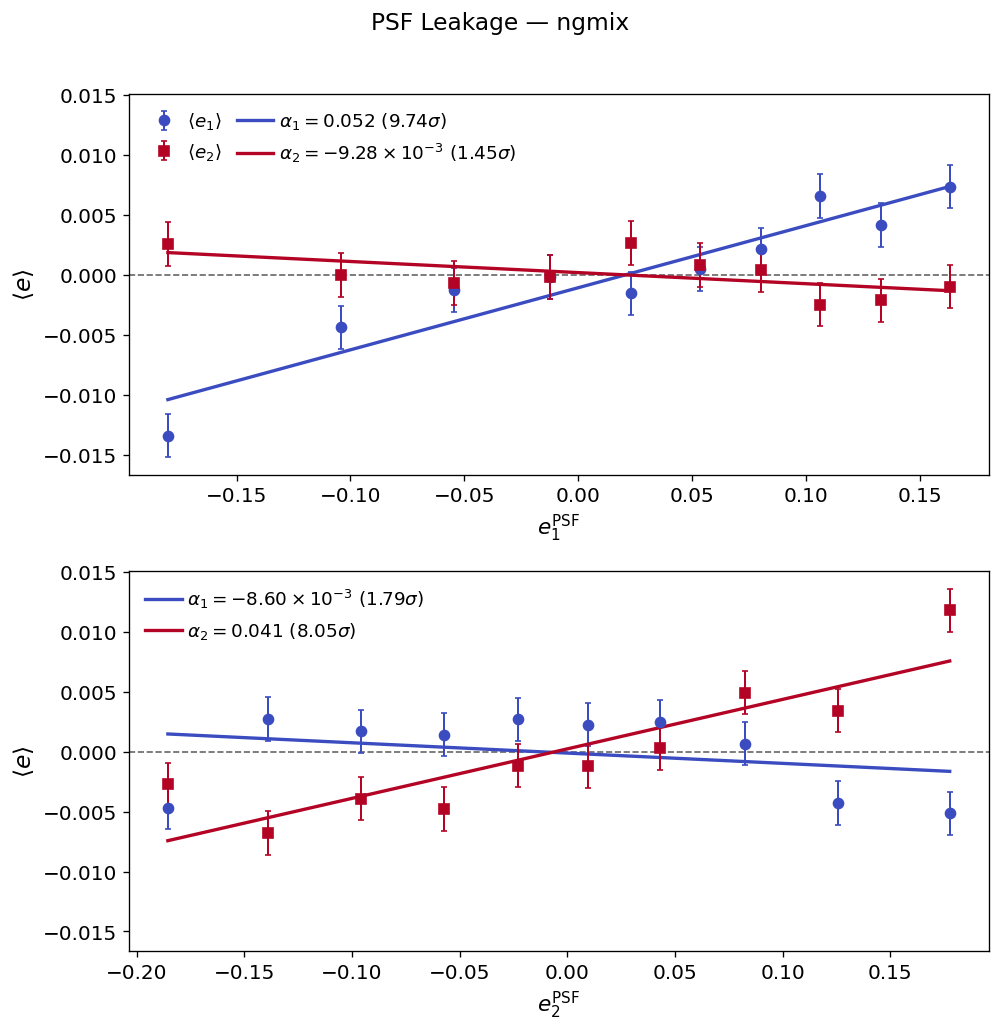

In [11]:
paneler_ng = plotter.PSFLeakagePanelMaker(
    e1_gal=e1_gal_lk,
    e2_gal=e2_gal_lk,
    NBIN=NBIN,
    MIN_COUNT=MIN_COUNT,
    CALIBRATE=CALIBRATE,
    njac=NJAC,
    color_e1=COLORS['ngmix'][0],
    color_e2=COLORS['ngmix'][1],
)

fig, axes = plt.subplots(2, 1, figsize=(8.5, 8.5), sharey=True)
for ax, (x, xlab) in zip(axes, x_list):
    paneler_ng.make_panel(ax, x_psf=x, xlab=xlab,
                          showe1e2_leg=(ax is axes[0]))

axes[0].set_ylabel(r'$\langle e \rangle$', fontsize=14)
axes[1].set_ylabel(r'$\langle e \rangle$', fontsize=14)
plt.suptitle('PSF Leakage — ngmix', fontsize=14, y=1.01)
plt.tight_layout()

plt.savefig(os.path.join(LEAKAGE_DIR, "psf_leakage_ngmix.png"), dpi=150, bbox_inches="tight")
print(f"Saved → {os.path.join(LEAKAGE_DIR, 'psf_leakage_ngmix.png')}")


## 9 · PSF leakage — ShearNet
*(skipped if ShearNet predictions are absent from the leakage file)*

Saved → /home/adfield/ShearNet/unit_tests/second/benchmarking/psf_leakage/psf_leakage_shearnet.png


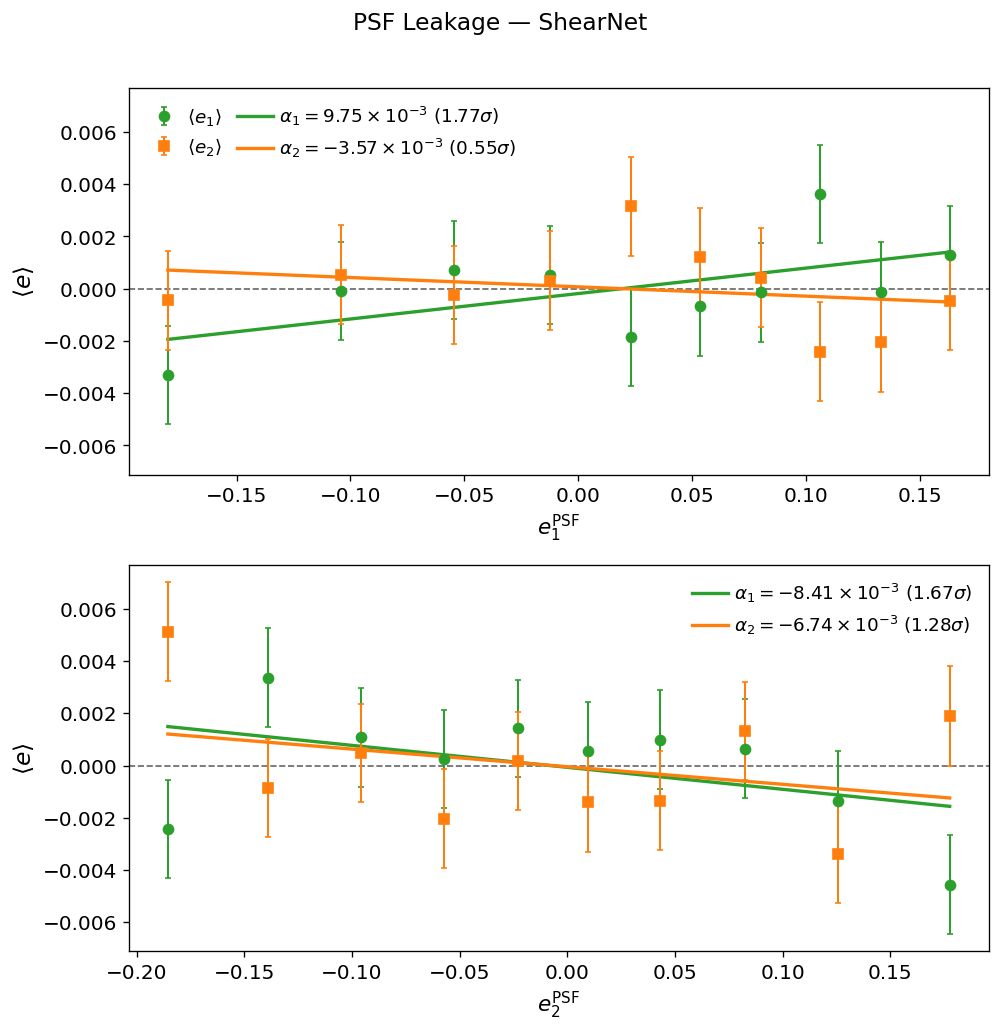

In [12]:
if not HAS_SN_LK:
    print('Skipping — no ShearNet predictions found in PSF leakage file.')
else:
    paneler_sn = plotter.PSFLeakagePanelMaker(
        e1_gal=e1_sn_lk,
        e2_gal=e2_sn_lk,
        NBIN=NBIN,
        MIN_COUNT=MIN_COUNT,
        CALIBRATE=CALIBRATE,
        njac=NJAC,
        color_e1=COLORS['shearnet'][0],
        color_e2=COLORS['shearnet'][1],
    )

    fig, axes = plt.subplots(2, 1, figsize=(8.5, 8.5), sharey=True)
    for ax, (x, xlab) in zip(axes, x_list):
        paneler_sn.make_panel(ax, x_psf=x, xlab=xlab,
                              showe1e2_leg=(ax is axes[0]))

    axes[0].set_ylabel(r'$\langle e \rangle$', fontsize=14)
    axes[1].set_ylabel(r'$\langle e \rangle$', fontsize=14)
    plt.suptitle('PSF Leakage — ShearNet', fontsize=14, y=1.01)
    plt.tight_layout()

    plt.savefig(os.path.join(LEAKAGE_DIR, "psf_leakage_shearnet.png"), dpi=150, bbox_inches="tight")
    print(f"Saved → {os.path.join(LEAKAGE_DIR, 'psf_leakage_shearnet.png')}")


## 10 · PSF leakage — side-by-side comparison
*(only when ShearNet is present)*

Saved → /home/adfield/ShearNet/unit_tests/second/benchmarking/psf_leakage/psf_leakage_comparison.png


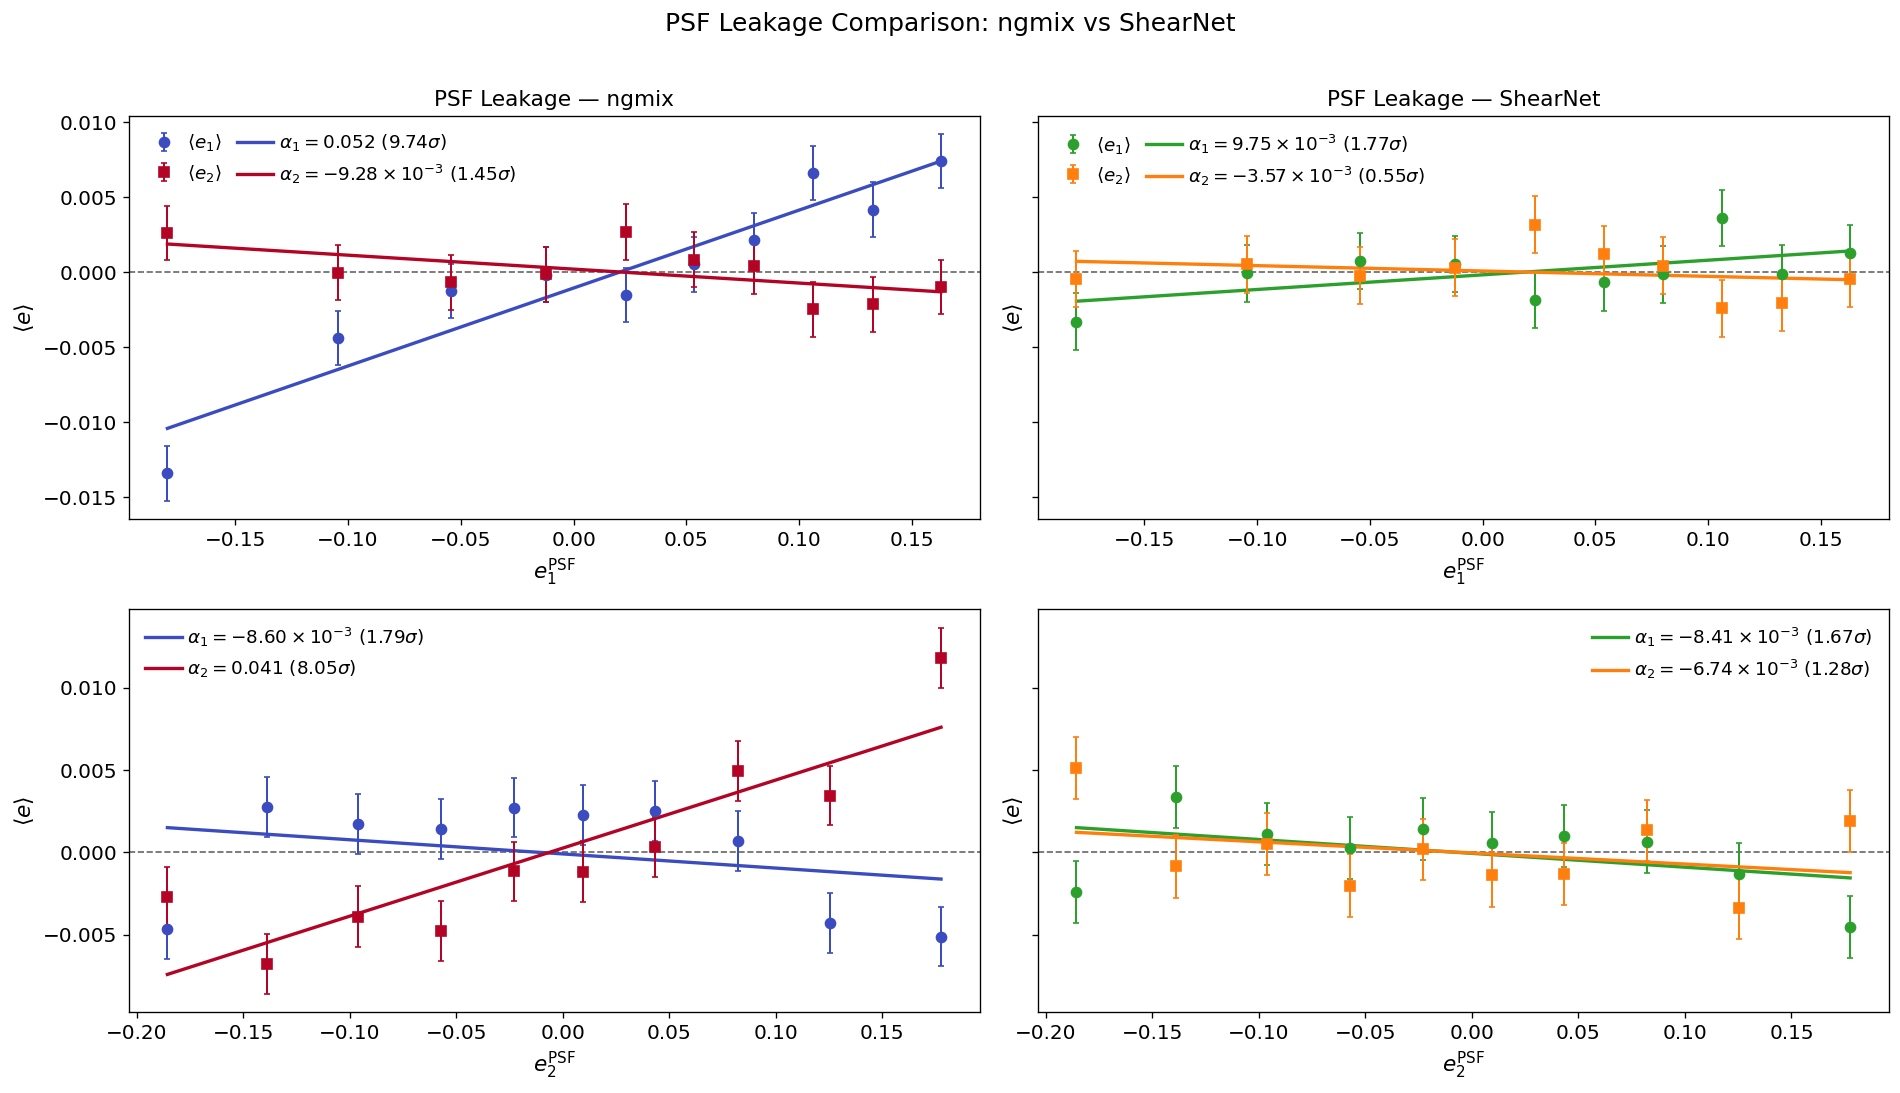

In [13]:
if not HAS_SN_LK:
    print('Skipping comparison — no ShearNet predictions found.')
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharey='row')

    for paneler, title, col_axes in [
        (paneler_ng, 'ngmix',    axes[:, 0]),
        (paneler_sn, 'ShearNet', axes[:, 1]),
    ]:
        for ax, (x, xlab) in zip(col_axes, x_list):
            paneler.make_panel(ax, x_psf=x, xlab=xlab,
                               showe1e2_leg=(ax is col_axes[0]))
        col_axes[0].set_title(f'PSF Leakage — {title}', fontsize=13)
        col_axes[0].set_ylabel(r'$\langle e \rangle$', fontsize=13)
        col_axes[1].set_ylabel(r'$\langle e \rangle$', fontsize=13)

    plt.suptitle('PSF Leakage Comparison: ngmix vs ShearNet', fontsize=15, y=1.01)
    plt.tight_layout()

    plt.savefig(os.path.join(LEAKAGE_DIR, "psf_leakage_comparison.png"), dpi=150, bbox_inches="tight")
    print(f"Saved → {os.path.join(LEAKAGE_DIR, 'psf_leakage_comparison.png')}")
